## **KNN Regression (Revisi)**

Pada bagian ini dilakukan pemodelan *K-Nearest Neighbors Regression* untuk memprediksi nilai konsentrasi gas NO₂ berdasarkan data hasil *lag 30*.  
Dataset yang digunakan: `data/NO2_Kwanyar_Preprocessed_Lag30.csv`

Langkah-langkah yang dilakukan:
1. Load dataset hasil *lag 30*
2. Eksplorasi data (tipe data, deskripsi statistik, missing values)
3. Normalisasi fitur numerik
4. Pembagian data *train-test*
5. Pelatihan model KNN Regression
6. Evaluasi model menggunakan MAE, RMSE, R², dan MAPE
7. Visualisasi hasil prediksi vs data aktual


In [42]:
# Import library utama
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## **Load Dataset**

In [43]:
# Load dataset hasil preprocessing dan lag 30
data_path = "data/NO2_Kwanyar_Lag30.csv"
df = pd.read_csv(data_path)

print("✅ Dataset berhasil dimuat.\n")
print(df.info())
df.head()


✅ Dataset berhasil dimuat.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 986 entries, 0 to 985
Data columns (total 32 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tanggal     986 non-null    object 
 1   NO2         986 non-null    float64
 2   NO2_lag_1   986 non-null    float64
 3   NO2_lag_2   986 non-null    float64
 4   NO2_lag_3   986 non-null    float64
 5   NO2_lag_4   986 non-null    float64
 6   NO2_lag_5   986 non-null    float64
 7   NO2_lag_6   986 non-null    float64
 8   NO2_lag_7   986 non-null    float64
 9   NO2_lag_8   986 non-null    float64
 10  NO2_lag_9   986 non-null    float64
 11  NO2_lag_10  986 non-null    float64
 12  NO2_lag_11  986 non-null    float64
 13  NO2_lag_12  986 non-null    float64
 14  NO2_lag_13  986 non-null    float64
 15  NO2_lag_14  986 non-null    float64
 16  NO2_lag_15  986 non-null    float64
 17  NO2_lag_16  986 non-null    float64
 18  NO2_lag_17  986 non-null    float64
 19  N

,Tanggal,NO2,NO2_lag_1,NO2_lag_2,NO2_lag_3,NO2_lag_4,NO2_lag_5,NO2_lag_6,NO2_lag_7,NO2_lag_8,...,NO2_lag_21,NO2_lag_22,NO2_lag_23,NO2_lag_24,NO2_lag_25,NO2_lag_26,NO2_lag_27,NO2_lag_28,NO2_lag_29,NO2_lag_30
0,2023-01-31,0.000032,0.000031,0.000030,0.000030,0.000029,0.000028,0.000028,0.000027,0.000027,...,0.000049,0.000049,0.000049,0.000043,0.000037,0.000031,0.000034,0.000034,0.000034,0.000034
1,2023-02-01,0.000032,0.000032,0.000031,0.000030,0.000030,0.000029,0.000028,0.000028,0.000027,...,0.000053,0.000049,0.000049,0.000049,0.000043,0.000037,0.000031,0.000034,0.000034,0.000034
2,2023-02-02,0.000033,0.000032,0.000032,0.000031,0.000030,0.000030,0.000029,0.000028,0.000028,...,0.000007,0.000053,0.000049,0.000049,0.000049,0.000043,0.000037,0.000031,0.000034,0.000034
3,2023-02-03,0.000034,0.000033,0.000032,0.000032,0.000031,0.000030,0.000030,0.000029,0.000028,...,0.000026,0.000007,0.000053,0.000049,0.000049,0.000049,0.000043,0.000037,0.000031,0.000034
4,2023-02-04,0.000034,0.000034,0.000033,0.000032,0.000032,0.000031,0.000030,0.000030,0.000029,...,0.000034,0.000026,0.000007,0.000053,0.000049,0.000049,0.000049,0.000043,0.000037,0.000031


## **Eksplorasi Data**

Langkah ini bertujuan untuk memahami struktur dataset:
- Melihat tipe data
- Statistik deskriptif
- Cek apakah ada nilai kosong


In [44]:
# Statistik deskriptif
display(df.describe())

# Cek missing values
print("Jumlah nilai kosong per kolom:")
print(df.isnull().sum())


,NO2,NO2_lag_1,NO2_lag_2,NO2_lag_3,NO2_lag_4,NO2_lag_5,NO2_lag_6,NO2_lag_7,NO2_lag_8,NO2_lag_9,...,NO2_lag_21,NO2_lag_22,NO2_lag_23,NO2_lag_24,NO2_lag_25,NO2_lag_26,NO2_lag_27,NO2_lag_28,NO2_lag_29,NO2_lag_30
count,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,...,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000
mean,0.000023,0.000023,0.000023,0.000023,0.000023,0.000023,0.000023,0.000023,0.000023,0.000023,...,0.000023,0.000023,0.000023,0.000023,0.000023,0.000023,0.000023,0.000023,0.000023,0.000023
std,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,...,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013,0.000013
min,-0.000076,-0.000076,-0.000076,-0.000076,-0.000076,-0.000076,-0.000076,-0.000076,-0.000076,-0.000076,...,-0.000076,-0.000076,-0.000076,-0.000076,-0.000076,-0.000076,-0.000076,-0.000076,-0.000076,-0.000076
25%,0.000014,0.000014,0.000014,0.000014,0.000014,0.000014,0.000014,0.000014,0.000014,0.000014,...,0.000014,0.000014,0.000014,0.000014,0.000014,0.000014,0.000014,0.000014,0.000014,0.000014
50%,0.000022,0.000022,0.000022,0.000022,0.000022,0.000022,0.000022,0.000022,0.000022,0.000022,...,0.000022,0.000022,0.000022,0.000022,0.000022,0.000022,0.000022,0.000022,0.000022,0.000022
75%,0.000030,0.000030,0.000030,0.000030,0.000030,0.000030,0.000030,0.000030,0.000030,0.000030,...,0.000030,0.000030,0.000030,0.000030,0.000030,0.000030,0.000030,0.000030,0.000031,0.000031
max,0.000096,0.000096,0.000096,0.000096,0.000096,0.000096,0.000096,0.000096,0.000096,0.000096,...,0.000096,0.000096,0.000096,0.000096,0.000096,0.000096,0.000096,0.000096,0.000096,0.000096


Jumlah nilai kosong per kolom:
Tanggal       0
NO2           0
NO2_lag_1     0
NO2_lag_2     0
NO2_lag_3     0
NO2_lag_4     0
NO2_lag_5     0
NO2_lag_6     0
NO2_lag_7     0
NO2_lag_8     0
NO2_lag_9     0
NO2_lag_10    0
NO2_lag_11    0
NO2_lag_12    0
NO2_lag_13    0
NO2_lag_14    0
NO2_lag_15    0
NO2_lag_16    0
NO2_lag_17    0
NO2_lag_18    0
NO2_lag_19    0
NO2_lag_20    0
NO2_lag_21    0
NO2_lag_22    0
NO2_lag_23    0
NO2_lag_24    0
NO2_lag_25    0
NO2_lag_26    0
NO2_lag_27    0
NO2_lag_28    0
NO2_lag_29    0
NO2_lag_30    0
dtype: int64


## **Persiapan Data untuk Model**

Pada tahap ini:
- Kolom `Tanggal` dihapus karena bukan fitur numerik.
- Kolom target adalah `NO2`.
- Data dibagi menjadi fitur (`X`) dan target (`y`).
- dan saya mengambil fitur dari lag >0,5


In [46]:
x = df[["NO2_lag_1"]]   # hanya gunakan lag 1 karena hanya itu yang > 0.5
y = df["NO2"]

print("Jumlah fitur:", x.shape[1])
print("Jumlah data:", x.shape[0])


Jumlah fitur: 1
Jumlah data: 986


## **Normalisasi Data**

Normalisasi digunakan agar seluruh fitur memiliki skala yang seragam.
Metode: **Min-Max Scaling (0–1)**.


In [49]:
# Normalisasi fitur numerik
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)

# Konversi kembali ke DataFrame agar mudah dibaca
x_scaled = pd.DataFrame(x_scaled, columns=x.columns)

x_scaled.head()


,NO2_lag_1
0,0.622174
1,0.625918
2,0.629662
3,0.633407
4,0.637151


## **Pembagian Data Train dan Test**

Data dibagi menjadi:
- 80% untuk data latih (*training*)
- 20% untuk data uji (*testing*)


In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"Data latih: {X_train.shape[0]} sampel")
print(f"Data uji  : {X_test.shape[0]} sampel")


Data latih: 788 sampel
Data uji  : 198 sampel


## **Pelatihan Model KNN Regression**

Model *K-Nearest Neighbors* akan mencari tetangga terdekat berdasarkan jarak Euclidean.  
Pada tahap awal digunakan `k=5` (dapat disesuaikan untuk uji parameter).


In [52]:
# Inisialisasi dan latih model
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

# Prediksi
y_pred = knn.predict(X_test)


## **Evaluasi Model**

Evaluasi dilakukan menggunakan beberapa metrik:
- **MAE (Mean Absolute Error)**
- **RMSE (Root Mean Squared Error)**
- **R² (Koefisien Determinasi)**
- **MAPE (Mean Absolute Percentage Error)** sesuai arahan dosen.


In [53]:
# Evaluasi
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"📈 MAE  : {mae:.4f}")
print(f"📉 RMSE : {rmse:.4f}")
print(f"🔹 R²   : {r2:.4f}")
print(f"📊 MAPE : {mape:.2f}%")


📈 MAE  : 0.0000
📉 RMSE : 0.0000
🔹 R²   : 0.2481
📊 MAPE : 87.57%


## **Visualisasi Hasil Prediksi vs Data Aktual**
Visualisasi digunakan untuk melihat sejauh mana hasil prediksi mendekati data aktual.


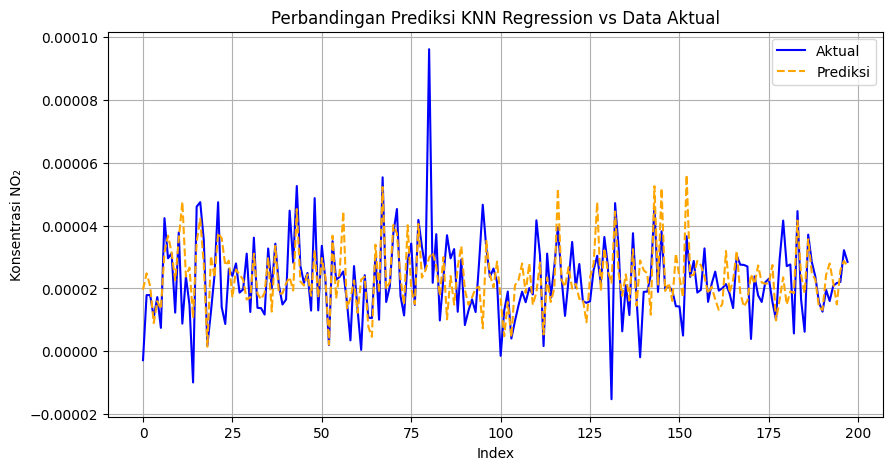

In [54]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Aktual", color="blue")
plt.plot(y_pred, label="Prediksi", color="orange", linestyle="--")
plt.title("Perbandingan Prediksi KNN Regression vs Data Aktual")
plt.xlabel("Index")
plt.ylabel("Konsentrasi NO₂")
plt.legend()
plt.grid(True)
plt.show()


## **Kesimpulan**

Model **KNN Regression** berhasil digunakan untuk memprediksi konsentrasi NO₂ berdasarkan hasil lag 30.  
Dari hasil evaluasi diperoleh nilai MAE, RMSE, R², dan MAPE yang mencerminkan tingkat akurasi model.  

Selanjutnya model dapat dioptimalkan dengan:
- Penentuan jumlah *neighbors (k)* terbaik menggunakan *GridSearchCV*
- Menambahkan fitur lain seperti suhu, kelembapan, atau arah angin jika tersedia


## **Menentukan Nilai K Optimal**

Untuk meningkatkan performa model, dilakukan pencarian jumlah tetangga terbaik (`k`).  
Nilai `k` diuji dari 1 hingga 20, dan akan dihitung nilai **MAE** untuk setiap `k`.  
Nilai `k` dengan MAE terkecil dianggap sebagai parameter optimal.


In [55]:
# Rentang nilai k yang akan diuji
k_values = range(1, 21)
mae_scores = []

for k in k_values:
    knn_temp = KNeighborsRegressor(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    y_pred_temp = knn_temp.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred_temp)
    mae_scores.append(mae)

# Temukan nilai k dengan MAE terkecil
best_k = k_values[np.argmin(mae_scores)]
best_mae = np.min(mae_scores)

print(f"✅ Nilai k optimal: {best_k}")
print(f"📉 MAE terkecil  : {best_mae:.4f}")


✅ Nilai k optimal: 20
📉 MAE terkecil  : 0.0000


## **Visualisasi Nilai K vs MAE**

Visualisasi ini memperlihatkan hubungan antara jumlah tetangga (`k`) dan error model.  
Tujuannya agar kita tahu pada titik mana model menghasilkan error terendah.


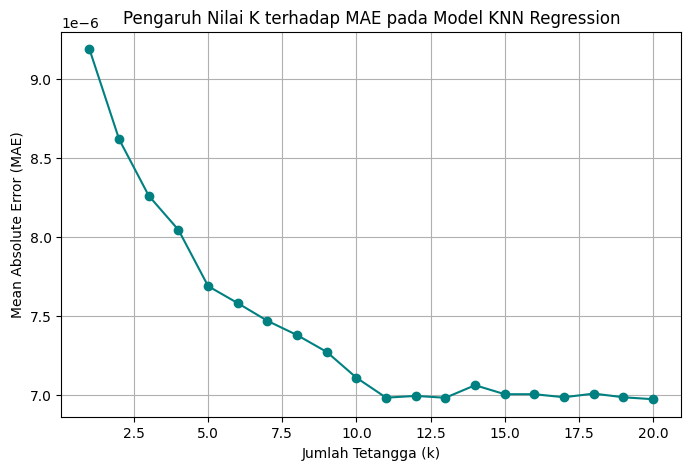

In [56]:
plt.figure(figsize=(8,5))
plt.plot(k_values, mae_scores, marker='o', linestyle='-', color='teal')
plt.title("Pengaruh Nilai K terhadap MAE pada Model KNN Regression")
plt.xlabel("Jumlah Tetangga (k)")
plt.ylabel("Mean Absolute Error (MAE)")
plt.grid(True)
plt.show()


## **Pelatihan Ulang Model dengan K Optimal**

Setelah menemukan nilai `k` terbaik, model akan dilatih ulang menggunakan parameter tersebut.


In [57]:
# Latih ulang model dengan k optimal
knn_best = KNeighborsRegressor(n_neighbors=best_k)
knn_best.fit(X_train, y_train)

# Prediksi ulang
y_pred_best = knn_best.predict(X_test)

# Evaluasi ulang
mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)
mape_best = np.mean(np.abs((y_test - y_pred_best) / y_test)) * 100

print(f"🔹 K Optimal : {best_k}")
print(f"📈 MAE  : {mae_best:.4f}")
print(f"📉 RMSE : {rmse_best:.4f}")
print(f"🔹 R²   : {r2_best:.4f}")
print(f"📊 MAPE : {mape_best:.2f}%")


🔹 K Optimal : 20
📈 MAE  : 0.0000
📉 RMSE : 0.0000
🔹 R²   : 0.3340
📊 MAPE : 73.06%


## **Visualisasi Hasil Akhir (Dengan K Optimal)**


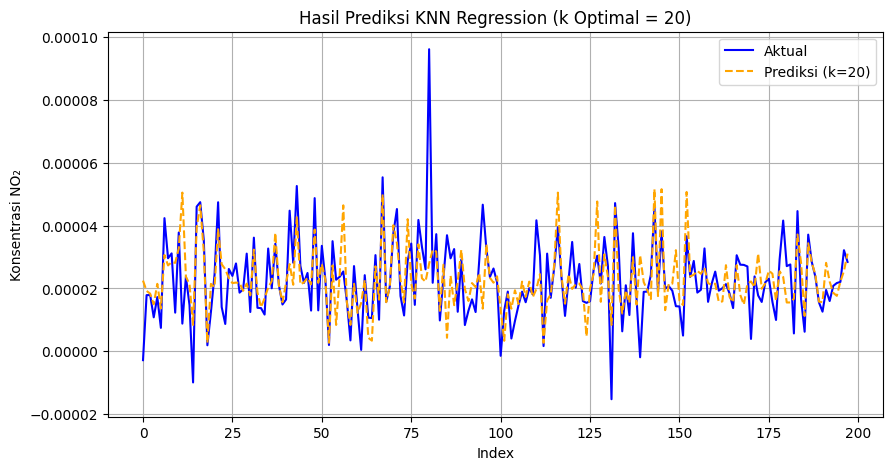

In [58]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Aktual", color="blue")
plt.plot(y_pred_best, label=f"Prediksi (k={best_k})", color="orange", linestyle="--")
plt.title(f"Hasil Prediksi KNN Regression (k Optimal = {best_k})")
plt.xlabel("Index")
plt.ylabel("Konsentrasi NO₂")
plt.legend()
plt.grid(True)
plt.show()


## **Kesimpulan Akhir**

- Nilai **k optimal** diperoleh dari uji error terendah (MAE terkecil).  
- Model KNN dengan `k = {{best_k}}` memberikan hasil prediksi yang lebih stabil dibanding nilai awal `k=5`.  
- Proses tuning ini membantu menghindari *underfitting* (jika k terlalu kecil) dan *overfitting* (jika k terlalu besar).

Selanjutnya, model dapat dikembangkan lebih lanjut dengan:
- *Cross-validation*
- Penambahan fitur cuaca eksternal
- Optimasi skala data atau bobot jarak (misalnya `weights='distance'`)
